# Download data

In [ ]:
!pip install git+https://github.com/rongardF/tvdatafeed.git

  Cloning https://github.com/rongardF/tvdatafeed.git to /tmp/pip-req-build-iidg1ctf
  Running command git clone --filter=blob:none --quiet https://github.com/rongardF/tvdatafeed.git /tmp/pip-req-build-iidg1ctf
  Resolved https://github.com/rongardF/tvdatafeed.git to commit e6f6aaa7de439ac6e454d9b26d2760ded8dc4923
  Preparing metadata (setup.py) ... done
  Created wheel for tvdatafeed: filename=tvdatafeed-2.1.0-py3-none-any.whl size=17532 sha256=aaa22c84ba3ded9511b2870f848a4671d7ef787bb3cc5abaef0e1e0056057797
  Stored in directory: /tmp/pip-ephem-wheel-cache-hai97kar/wheels/88/4b/d2/ce1c8432f33d4ab6d148d6ece31055eadadda0a5dd9fb76366
Successfully built tvdatafeed


# Import Thư Viện

In [ ]:
import numpy as np
import pandas as pd
from tvDatafeed import TvDatafeed, Interval

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import os

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
device

device(type='cuda')

# Data

In [ ]:
tv = TvDatafeed()
ticker = 'HPG'
df = tv.get_hist(
    symbol=ticker,
    exchange='HOSE',
    interval=Interval.in_daily,
    n_bars=5000
)

print(df.tail(5))

                       symbol     open     high      low    close      volume
datetime                                                                     
2025-12-25 02:00:00  HOSE:HPG  26550.0  26650.0  26250.0  26250.0  41032154.0
2025-12-26 02:00:00  HOSE:HPG  27100.0  27700.0  26650.0  26900.0  95978734.0
2025-12-29 02:00:00  HOSE:HPG  27000.0  27000.0  26650.0  26700.0  18168727.0
2025-12-30 02:00:00  HOSE:HPG  26700.0  26850.0  26500.0  26500.0  24743921.0
2025-12-31 02:00:00  HOSE:HPG  26450.0  26600.0  26350.0  26400.0  21874703.0


In [ ]:
# Đưa datetime từ index ra cột
df.reset_index(inplace=True)

# Đổi tên cho giống vnstock
df.rename(columns={
    'datetime': 'time'
}, inplace=True)

# Chuyển giá về đơn vị "nghìn đồng"
for col in ['open', 'high', 'low', 'close']:
    df[col] = df[col] / 1000

In [ ]:
df

,time,symbol,open,high,low,close,volume
0,2012-01-13 02:00:00,HOSE:HPG,0.870603,0.870603,0.855056,0.860238,4.863765e+06
1,2012-01-16 02:00:00,HOSE:HPG,0.865421,0.891331,0.865421,0.870603,3.999466e+06
2,2012-01-17 02:00:00,HOSE:HPG,0.870603,0.880967,0.865421,0.870603,3.537491e+06
3,2012-01-18 02:00:00,HOSE:HPG,0.870603,0.875785,0.865421,0.875785,2.337021e+06
4,2012-01-19 02:00:00,HOSE:HPG,0.880967,0.906878,0.875785,0.906878,4.317867e+06
...,...,...,...,...,...,...,...
3467,2025-12-25 02:00:00,HOSE:HPG,26.550000,26.650000,26.250000,26.250000,4.103215e+07
3468,2025-12-26 02:00:00,HOSE:HPG,27.100000,27.700000,26.650000,26.900000,9.597873e+07
3469,2025-12-29 02:00:00,HOSE:HPG,27.000000,27.000000,26.650000,26.700000,1.816873e+07
3470,2025-12-30 02:00:00,HOSE:HPG,26.700000,26.850000,26.500000,26.500000,2.474392e+07


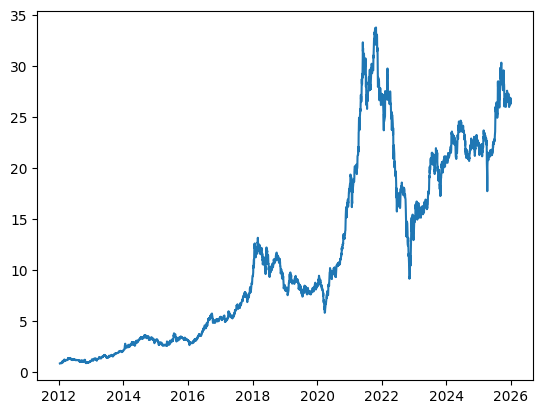

In [ ]:
plt1 = plt.plot(df['time'], df['close'])
plt1


In [ ]:
ma100 = df.close.rolling(100).mean()
ma200 = df.close.rolling(200).mean()
ma50 = df.close.rolling(50).mean()
ma20 = df.close.rolling(20).mean()

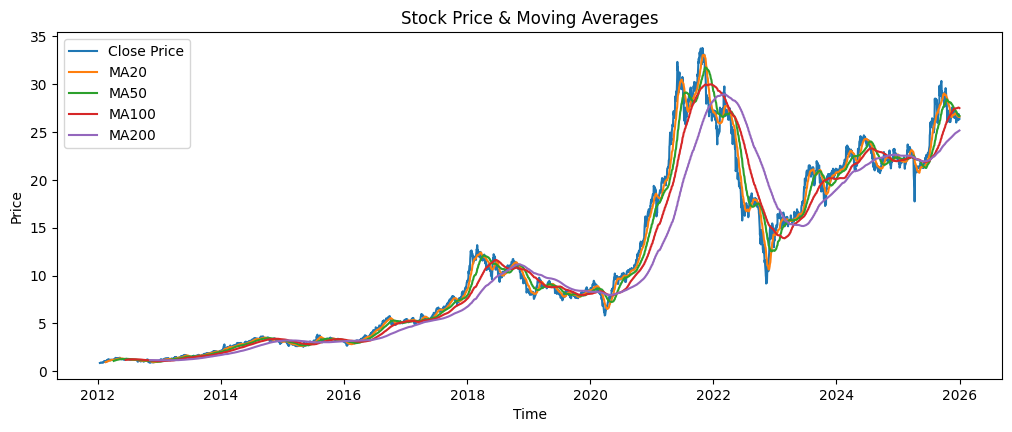

In [ ]:
plt.figure(figsize=(12.2, 4.5))

plt.plot(df['time'], df['close'], label='Close Price')
plt.plot(df['time'], ma20,  label='MA20')
plt.plot(df['time'], ma50,  label='MA50')
plt.plot(df['time'], ma100, label='MA100')
plt.plot(df['time'], ma200, label='MA200')

plt.legend()
plt.title('Stock Price & Moving Averages')
plt.xlabel('Time')
plt.ylabel('Price')

plt.show()


# Chia tập dữ liệu huấn luyện

In [ ]:
split = int(len(df) * 0.7)

data_training = df[['close']].iloc[:split].copy()
data_testing  = df[['close']].iloc[split:].copy()

print(data_training.shape)
print(data_testing.shape)

(2430, 1)
(1042, 1)


# Scale Data

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))

In [ ]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.00000000e+00],
       [3.14649407e-04],
       [3.14649407e-04],
       ...,
       [9.98230835e-01],
       [1.00000000e+00],
       [9.84077512e-01]])

In [ ]:
data_training_array.shape

(2430, 1)

In [ ]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
  x_train.append(data_training_array[i-100: i])
  y_train.append(data_training_array[i, 0])

In [ ]:
x_train, y_train = np.array(x_train), np.array(y_train)

In [ ]:
x_train.shape

(2330, 100, 1)

# Model ML

In [ ]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [ ]:
model = Sequential()

model.add(LSTM(
    units=64,
    return_sequences=True,
    input_shape=(x_train.shape[1], 1)
))
model.add(Dropout(0.2))

model.add(LSTM(
    units=64,
    return_sequences=False
))
model.add(Dropout(0.2))

model.add(Dense(1))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0141
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0010
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0012
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 8.2003e-04
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0010
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.3386e-04
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.8435e-04
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.2014e-04
Epoch 10/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.3848e-04
Epoch 11/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 6.7156e-04
Epoch 12/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.1853e-04
Epoch 13/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 6.3048e-04
Epoch 14/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.4227e-04
Epoch 15/50
73/73 ━━━━━━━━━━━━━━━━━

# Save model

In [ ]:
import os
save_dir = '/content/drive/MyDrive/stock_market(new)/process/exp/trainbase_04012026'
os.makedirs(save_dir, exist_ok=True)

In [ ]:
save_path = os.path.join(save_dir, 'model_keras_04012026_C2.keras')
model.save(save_path)

In [ ]:
data_testing.head()

,close
2430,32.459172
2431,32.342622
2432,32.400897
2433,32.808822
2434,32.983647


In [ ]:
data_training.tail(100)

,close
2330,30.069897
2331,30.944022
2332,31.235397
2333,31.002297
2334,30.186447
...,...
2425,32.109522
2426,32.808822
2427,33.741222
2428,33.799497


In [ ]:
past_100_days = data_training.tail(100)

In [ ]:
final_df = pd.concat(
    [past_100_days, data_testing],
    ignore_index=True
)


In [ ]:
final_df.head()

,close
0,30.069897
1,30.944022
2,31.235397
3,31.002297
4,30.186447


In [ ]:
input_data = scaler.transform(final_df)
input_data

array([[0.88677342],
       [0.9133109 ],
       [0.92215672],
       ...,
       [0.78446702],
       [0.77839523],
       [0.77535934]])

In [ ]:
input_data.shape

(1142, 1)

# Training test

In [ ]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
  x_test.append(input_data[i - 100: i])
  y_test.append(input_data[i, 0])

In [ ]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [ ]:
print(x_test.shape)
print(y_test.shape)

(1042, 100, 1)
(1042,)


# Prediction

In [ ]:
y_predicted = model.predict(x_test)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [ ]:
y_predicted.shape

(1042, 1)

In [ ]:
y_test

array([0.9593092 , 0.95577087, 0.95754003, ..., 0.78446702, 0.77839523,
       0.77535934])

In [ ]:
y_predicted

array([[0.9913231 ],
       [0.9880258 ],
       [0.9821148 ],
       ...,
       [0.79075134],
       [0.79150283],
       [0.79098797]], dtype=float32)

In [ ]:
# scaler.scale_

In [ ]:
# scale_factor = 1/0.03041272
# y_predicted = y_predicted * scale_factor
# y_test = y_test * scale_factor


In [ ]:
y_predicted = scaler.inverse_transform(y_predicted)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

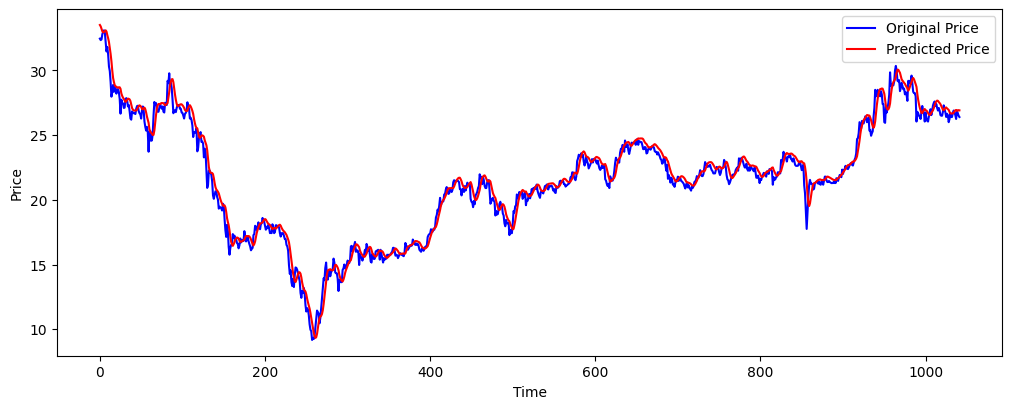

In [ ]:
plt.figure(figsize=(12.2, 4.5))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [ ]:
test_time = df['time'][-len(y_test):]

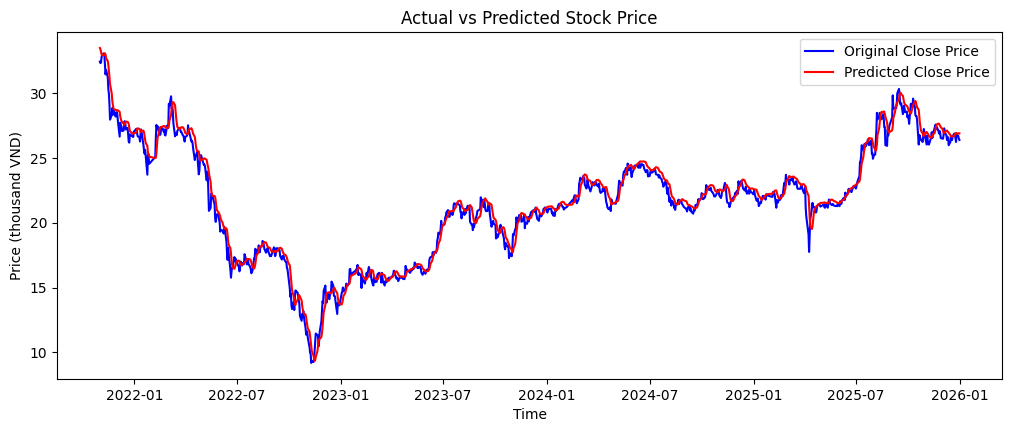

In [ ]:
plt.figure(figsize=(12.2, 4.5))

plt.plot(test_time, y_test, color='blue', label='Original Close Price')
plt.plot(test_time, y_predicted, color='red', label='Predicted Close Price')

plt.xlabel('Time')
plt.ylabel('Price (thousand VND)')
plt.title('Actual vs Predicted Stock Price')
plt.legend()
plt.show()


# Check Predict Price for MODEL

In [ ]:
# In ra 5 giá trị cuối để so sánh kiểm tra
print(df[['time','close']].tail())
print(y_test[-5:])
print(y_predicted[-5:])

                    time  close
3467 2025-12-25 02:00:00  26.25
3468 2025-12-26 02:00:00  26.90
3469 2025-12-29 02:00:00  26.70
3470 2025-12-30 02:00:00  26.50
3471 2025-12-31 02:00:00  26.40
[[26.25]
 [26.9 ]
 [26.7 ]
 [26.5 ]
 [26.4 ]]
[[26.941126]
 [26.876593]
 [26.907001]
 [26.931755]
 [26.914795]]
